# Prediksi Adopsi AI pada Developer

Notebook ini membandingkan model klasifikasi untuk dua target:

- `AISelect`: penggunaan alat AI secara umum.
- `AIAgents`: penggunaan AI Agent.

Alur analisis mencakup pemuatan data, feature engineering, eksplorasi data, penanganan class imbalance, evaluasi model, hyperparameter tuning, dan interpretasi feature importance.

## 1. Setup lingkungan

Notebook dirancang untuk Google Colab. Jalankan instalasi satu kali sebelum mengimpor library.

In [1]:
!pip install -q catboost imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)

## 2. Membaca dataset

Lokasi default: `/content/drive/MyDrive/Colab Notebooks/PROJECT ML/dataset/results.csv`. Ubah `PROJECT_DIR` bila folder berbeda.

In [3]:
from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/Colab Notebooks/PROJECT ML')
candidate_dirs = [PROJECT_DIR / 'dataset', Path('/content/dataset'), Path('/content')]
DATA_DIR = next((path for path in candidate_dirs if (path / 'results.csv').exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError('results.csv tidak ditemukan.')

data_path = DATA_DIR / 'results.csv'
REQUIRED_COLUMNS = [
    'Age',
    'YearsCode',
    'WorkExp',
    'CompTotal',
    'DevType',
    'OpSysProfessional use',
    'DevEnvsHaveWorkedWith',
    'LanguageHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'AISelect',
    'AIAgents',
    'AISent',
]

available_columns = pd.read_csv(data_path, nrows=0).columns
missing_columns = sorted(set(REQUIRED_COLUMNS) - set(available_columns))

if missing_columns:
    raise ValueError(f'Kolom wajib tidak ditemukan: {missing_columns}')

df_raw = pd.read_csv(data_path, usecols=REQUIRED_COLUMNS, low_memory=False)
print(f'Dataset berhasil dimuat: {df_raw.shape[0]:,} baris')
display(df_raw.head(3))

Mounted at /content/drive
Dataset berhasil dimuat: 49,191 baris


,Age,WorkExp,YearsCode,DevType,CompTotal,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,WebframeHaveWorkedWith,DevEnvsHaveWorkedWith,OpSysProfessional use,AISelect,AISent,AIAgents
0,25-34 years old,8.0,14.0,"Developer, mobile",52800.0,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,NaN,Android Studio;Notepad++;Visual Studio;Visual ...,Windows;MacOS;Android;iOS;iPadOS,"Yes, I use AI tools monthly or infrequently",Indifferent,"Yes, I use AI agents at work monthly or infreq..."
1,25-34 years old,2.0,10.0,"Developer, back-end",90000.0,Java,Dynamodb;MongoDB,Spring Boot,IntelliJ IDEA;PyCharm;Visual Studio Code;Xcode,MacOS,"Yes, I use AI tools weekly",Indifferent,"No, and I don't plan to"
2,35-44 years old,10.0,12.0,"Developer, front-end",2214000.0,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Next.js;Node.js;React,Visual Studio Code,MacOS,"Yes, I use AI tools daily",Favorable,"Yes, I use AI agents at work weekly"


## 3. Feature engineering

Kolom survei diberi nama ringkas. Target yang diawali `Yes` dipetakan ke 1, sedangkan `No` dipetakan ke 0. Rentang umur dan jawaban khusus `YearsCode` diubah menjadi angka.

In [4]:
NUMERIC_FEATURES = ['Age', 'YearsCode', 'WorkExp', 'CompTotal']
CATEGORICAL_FEATURES = [
    'DevType',
    'OpSys',
    'DevEnvs',
    'Language',
    'Webframe',
    'Database',
    'AISent',
]

FEATURE_COLUMNS = {
    'Age': 'Age',
    'YearsCode': 'YearsCode',
    'WorkExp': 'WorkExp',
    'CompTotal': 'CompTotal',
    'DevType': 'DevType',
    'OpSys': 'OpSysProfessional use',
    'DevEnvs': 'DevEnvsHaveWorkedWith',
    'Language': 'LanguageHaveWorkedWith',
    'Webframe': 'WebframeHaveWorkedWith',
    'Database': 'DatabaseHaveWorkedWith',
    'AISent': 'AISent',
}


def age_to_number(value):
    if pd.isna(value):
        return np.nan

    text = str(value)
    if 'Under 18' in text:
        return 17
    if '65 years or older' in text:
        return 70

    numbers = [float(number) for number in re.findall(r'\d+', text)]
    return np.mean(numbers) if numbers else np.nan


def years_code_to_number(value):
    if pd.isna(value):
        return np.nan

    special_values = {
        'Less than 1 year': 0.5,
        'More than 50 years': 51,
    }
    return pd.to_numeric(special_values.get(str(value), value), errors='coerce')


def target_to_binary(series):
    text = series.astype('string')
    result = pd.Series(np.nan, index=series.index, dtype='float64')
    result.loc[text.str.startswith('Yes', na=False)] = 1
    result.loc[text.str.startswith('No', na=False)] = 0
    return result


X = (
    df_raw[list(FEATURE_COLUMNS.values())]
    .rename(columns={source: alias for alias, source in FEATURE_COLUMNS.items()})
    .copy()
)

X['Age'] = X['Age'].map(age_to_number)
X['YearsCode'] = X['YearsCode'].map(years_code_to_number)
X['WorkExp'] = pd.to_numeric(X['WorkExp'], errors='coerce')
X['CompTotal'] = pd.to_numeric(X['CompTotal'], errors='coerce')

Y_1 = target_to_binary(df_raw['AISelect'])
Y_2 = target_to_binary(df_raw['AIAgents'])

print(f'Fitur yang digunakan: {X.columns.tolist()}')
display(X.head())
del df_raw

Fitur yang digunakan: ['Age', 'YearsCode', 'WorkExp', 'CompTotal', 'DevType', 'OpSys', 'DevEnvs', 'Language', 'Webframe', 'Database', 'AISent']


,Age,YearsCode,WorkExp,CompTotal,DevType,OpSys,DevEnvs,Language,Webframe,Database,AISent
0,29.5,14.0,8.0,52800.0,"Developer, mobile",Windows;MacOS;Android;iOS;iPadOS,Android Studio;Notepad++;Visual Studio;Visual ...,Bash/Shell (all shells);Dart;SQL,NaN,Cloud Firestore;PostgreSQL,Indifferent
1,29.5,10.0,2.0,90000.0,"Developer, back-end",MacOS,IntelliJ IDEA;PyCharm;Visual Studio Code;Xcode,Java,Spring Boot,Dynamodb;MongoDB,Indifferent
2,39.5,12.0,10.0,2214000.0,"Developer, front-end",MacOS,Visual Studio Code,Dart;HTML/CSS;JavaScript;TypeScript,Next.js;Node.js;React,MongoDB;MySQL;PostgreSQL,Favorable
3,39.5,5.0,4.0,31200.0,"Developer, back-end",Windows;Ubuntu,NaN,Java;Kotlin;SQL,Spring Boot,NaN,Favorable
4,39.5,22.0,21.0,60000.0,Engineering manager,Windows;Ubuntu;Debian,Eclipse;IntelliJ IDEA;Jupyter Notebook/Jupyter...,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Favorable


## 4. Analisis eksploratif

Distribusi `AISent` memberi gambaran awal mengenai sentimen developer terhadap AI.

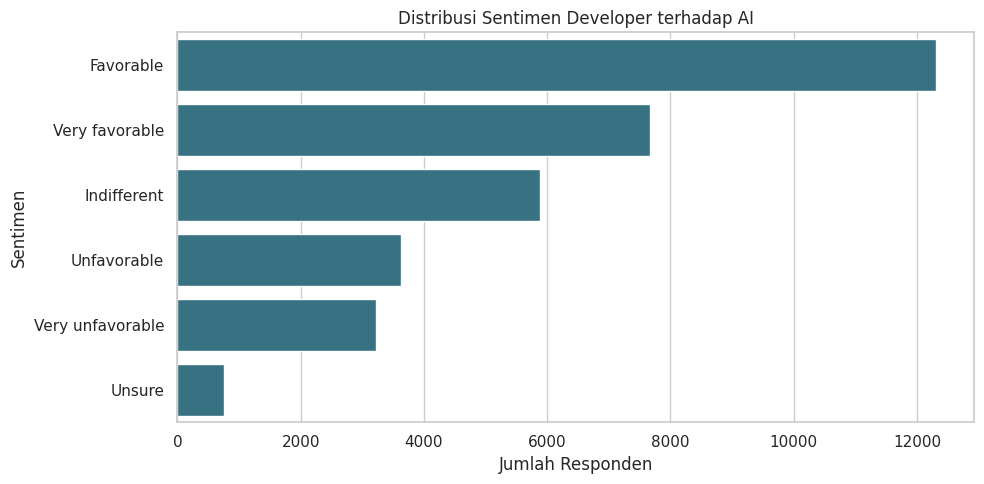

In [5]:
sentiment_order = X['AISent'].value_counts().index

plt.figure(figsize=(10, 5))
sns.countplot(data=X, y='AISent', order=sentiment_order, color='#2a788e')
plt.title('Distribusi Sentimen Developer terhadap AI')
plt.xlabel('Jumlah Responden')
plt.ylabel('Sentimen')
plt.tight_layout()
plt.show()

## 5. Pemodelan awal

`SMOTENC` diterapkan hanya pada training set. Kategori multi-pilihan dipadatkan berdasarkan kategori terpopuler di training set, nilai numerik ekstrem dibatasi, dan `CompTotal` ditransformasi dengan `log1p`.

In [6]:
def metric_row(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'F1 Tidak': f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'F1 Ya': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'F1 Macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

def train_and_evaluate(X, y, scenario_name):
    valid_target = y.notna()
    X_scenario = X.loc[valid_target].copy()
    y_scenario = y.loc[valid_target].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scenario,
        y_scenario,
        test_size=0.20,
        stratify=y_scenario,
        random_state=RANDOM_STATE,
    )

    # Padatkan jawaban seperti 'Python;SQL;JavaScript' menjadi satu kategori umum.
    # Daftar kategori dipelajari dari training set agar tidak terjadi leakage.
    X_train_compact = X_train.copy()
    X_test_compact = X_test.copy()
    for column in CATEGORICAL_FEATURES:
        tokens = (
            X_train[column].dropna().astype(str).str.split(';').explode().str.strip()
        )
        common_categories = tokens[tokens.ne('')].value_counts().head(25).index.tolist()
        category_rank = {value: rank for rank, value in enumerate(common_categories)}

        def select_category(value):
            if pd.isna(value):
                return 'Tidak diketahui'
            choices = [item.strip() for item in str(value).split(';')]
            known = [item for item in choices if item in category_rank]
            return min(known, key=category_rank.get) if known else 'Lainnya'

        X_train_compact[column] = X_train[column].map(select_category)
        X_test_compact[column] = X_test[column].map(select_category)

    # Bersihkan nilai numerik ekstrem menggunakan batas dari training set saja.
    # CompTotal memiliki satuan mata uang berbeda dan beberapa nilai sangat besar.
    for column in NUMERIC_FEATURES:
        train_values = pd.to_numeric(
            X_train_compact[column], errors='coerce'
        ).replace([np.inf, -np.inf], np.nan)
        test_values = pd.to_numeric(
            X_test_compact[column], errors='coerce'
        ).replace([np.inf, -np.inf], np.nan)

        lower = train_values.quantile(0.005)
        upper = train_values.quantile(0.995)
        if pd.notna(lower) and pd.notna(upper) and lower < upper:
            train_values = train_values.clip(lower=lower, upper=upper)
            test_values = test_values.clip(lower=lower, upper=upper)

        if column == 'CompTotal':
            train_values = np.log1p(train_values.clip(lower=0))
            test_values = np.log1p(test_values.clip(lower=0))

        X_train_compact[column] = train_values
        X_test_compact[column] = test_values

    numeric_imputer = SimpleImputer(strategy='median')
    categorical_imputer = SimpleImputer(strategy='constant', fill_value='Tidak diketahui')
    ordinal_encoder = OrdinalEncoder(
        handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.float32
    )

    X_train_ready = X_train_compact.copy()
    X_test_ready = X_test_compact.copy()
    X_train_ready[NUMERIC_FEATURES] = numeric_imputer.fit_transform(
        X_train_compact[NUMERIC_FEATURES]
    ).astype(np.float32)
    X_test_ready[NUMERIC_FEATURES] = numeric_imputer.transform(
        X_test_compact[NUMERIC_FEATURES]
    ).astype(np.float32)

    train_categories = categorical_imputer.fit_transform(X_train_compact[CATEGORICAL_FEATURES])
    test_categories = categorical_imputer.transform(X_test_compact[CATEGORICAL_FEATURES])
    X_train_ready[CATEGORICAL_FEATURES] = ordinal_encoder.fit_transform(train_categories)
    X_test_ready[CATEGORICAL_FEATURES] = ordinal_encoder.transform(test_categories)

    categorical_indices = [X_train_ready.columns.get_loc(c) for c in CATEGORICAL_FEATURES]
    min_class_count = int(y_train.value_counts().min())
    k_neighbors = min(5, min_class_count - 1)
    if k_neighbors < 1:
        raise ValueError('Kelas minoritas membutuhkan minimal 2 sampel untuk SMOTENC.')

    smote = SMOTENC(
        categorical_features=categorical_indices,
        k_neighbors=k_neighbors,
        random_state=RANDOM_STATE,
    )
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_ready, y_train)
    X_train_balanced = pd.DataFrame(X_train_balanced, columns=X_train_ready.columns)
    y_train_balanced = pd.Series(y_train_balanced, name='target')

    linear_preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), NUMERIC_FEATURES),
            ('cat', OneHotEncoder(handle_unknown='ignore', dtype=np.float32), CATEGORICAL_FEATURES),
        ]
    )
    tree_preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', NUMERIC_FEATURES),
            ('cat', OneHotEncoder(handle_unknown='ignore', dtype=np.float32), CATEGORICAL_FEATURES),
        ]
    )

    models = {
        'Logistic Regression': Pipeline([
            ('preprocessor', linear_preprocessor),
            ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]),
        'Random Forest': Pipeline([
            ('preprocessor', tree_preprocessor),
            ('model', RandomForestClassifier(
                n_estimators=120, max_depth=18, min_samples_leaf=2,
                n_jobs=-1, random_state=RANDOM_STATE
            )),
        ]),
    }

    predictions = {}
    reports = {}
    for model_name, model in models.items():
        print(f'Melatih {model_name}...')
        model.fit(X_train_balanced, y_train_balanced)
        predictions[model_name] = model.predict(X_test_ready)

    X_train_catboost = X_train_balanced.copy()
    X_test_catboost = X_test_ready.copy()
    for column in CATEGORICAL_FEATURES:
        X_train_catboost[column] = X_train_catboost[column].round().astype(int).astype(str)
        X_test_catboost[column] = X_test_catboost[column].round().astype(int).astype(str)

    print('Melatih CatBoost...')
    catboost_model = CatBoostClassifier(
        iterations=250,
        depth=6,
        learning_rate=0.10,
        loss_function='Logloss',
        eval_metric='F1',
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=2,
    )
    catboost_model.fit(
        X_train_catboost, y_train_balanced, cat_features=CATEGORICAL_FEATURES
    )
    models['CatBoost'] = catboost_model
    predictions['CatBoost'] = catboost_model.predict(X_test_catboost).astype(int).ravel()

    print(f'\n{"=" * 72}\n{scenario_name}\n{"=" * 72}')
    summary_rows = []
    for model_name, y_pred in predictions.items():
        print(f'\n--- {model_name} ---')
        print(classification_report(
            y_test, y_pred, target_names=['Tidak', 'Ya'], digits=4, zero_division=0
        ))
        reports[model_name] = classification_report(
            y_test, y_pred, target_names=['Tidak', 'Ya'],
            output_dict=True, zero_division=0
        )
        summary_rows.append(metric_row(model_name, y_test, y_pred))

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    for axis, (model_name, y_pred) in zip(axes, predictions.items()):
        matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
        sns.heatmap(
            matrix, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Tidak', 'Ya'], yticklabels=['Tidak', 'Ya'], ax=axis
        )
        axis.set_title(model_name)
        axis.set_xlabel('Prediksi')
        axis.set_ylabel('Aktual')
    fig.suptitle(f'Confusion Matrix - {scenario_name}', fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame(summary_rows).sort_values('F1 Macro', ascending=False)
    print('Ringkasan F1-score:')
    display(summary.style.format({
        'F1 Tidak': '{:.4f}', 'F1 Ya': '{:.4f}', 'F1 Macro': '{:.4f}'
    }))

    importance = pd.Series(
        catboost_model.get_feature_importance(),
        index=X_train_catboost.columns,
    ).sort_values(ascending=True)
    importance.plot.barh(figsize=(8, 5), color='#2a788e')
    plt.title(f'Feature Importance CatBoost - {scenario_name}')
    plt.xlabel('Importance')
    plt.ylabel('Fitur')
    plt.tight_layout()
    plt.show()

    print(f'Training awal: {len(X_train):,} | setelah SMOTENC: {len(X_train_balanced):,} | testing: {len(X_test):,}')
    return {
        'models': models,
        'predictions': predictions,
        'reports': reports,
        'summary': summary,
        'feature_importance': importance.sort_values(ascending=False),
        'y_test': y_test,
    }

## 6. Skenario A: Penggunaan AI umum

Fokus evaluasi: `F1 Tidak`, `F1 Ya`, dan `F1 Macro`.

Melatih Logistic Regression...
Melatih Random Forest...
Melatih CatBoost...

Prediksi AISelect

--- Logistic Regression ---
              precision    recall  f1-score   support

       Tidak     0.5758    0.7807    0.6628      1450
          Ya     0.9334    0.8425    0.8856      5294

    accuracy                         0.8292      6744
   macro avg     0.7546    0.8116    0.7742      6744
weighted avg     0.8565    0.8292    0.8377      6744


--- Random Forest ---
              precision    recall  f1-score   support

       Tidak     0.5895    0.7793    0.6712      1450
          Ya     0.9337    0.8513    0.8906      5294

    accuracy                         0.8359      6744
   macro avg     0.7616    0.8153    0.7809      6744
weighted avg     0.8597    0.8359    0.8435      6744


--- CatBoost ---
              precision    recall  f1-score   support

       Tidak     0.6589    0.6862    0.6723      1450
          Ya     0.9131    0.9027    0.9079      5294

    accuracy     

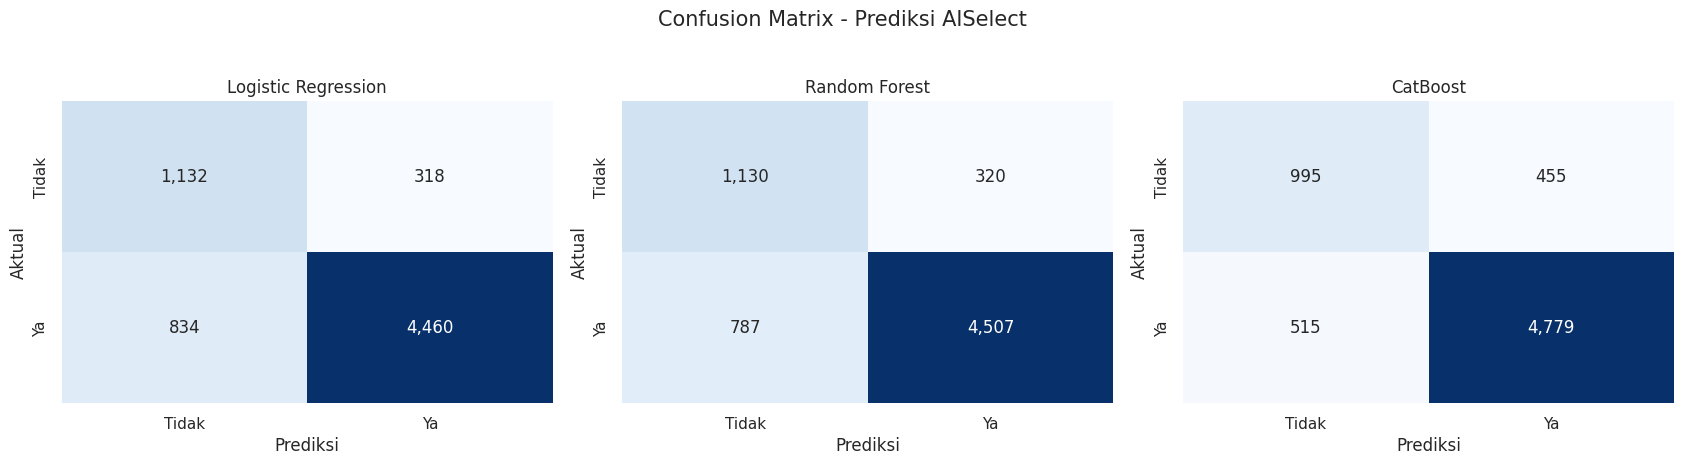

Ringkasan F1-score:


,Model,F1 Tidak,F1 Ya,F1 Macro
2,CatBoost,0.6723,0.9079,0.7901
1,Random Forest,0.6712,0.8906,0.7809
0,Logistic Regression,0.6628,0.8856,0.7742


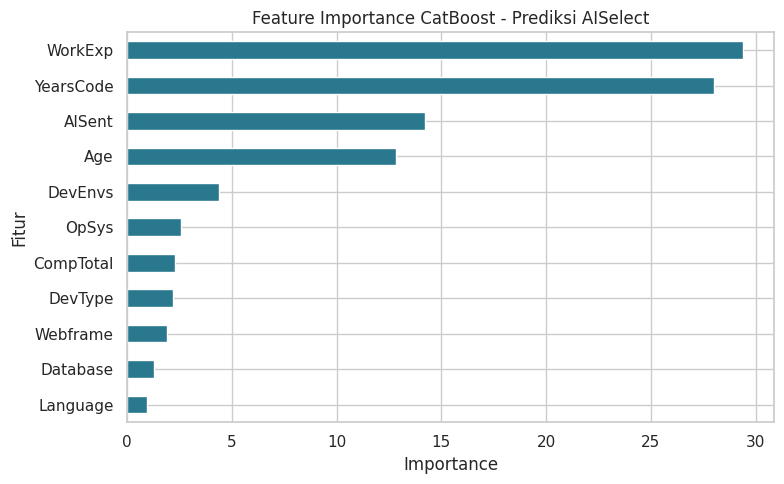

Training awal: 26,976 | setelah SMOTENC: 42,350 | testing: 6,744


In [7]:
result_ai_select = train_and_evaluate(X, Y_1, 'Prediksi AISelect')

## 7. Skenario B: Adopsi AI Agent

Skenario ini lebih menantang karena distribusi target lebih tidak seimbang.

Melatih Logistic Regression...
Melatih Random Forest...
Melatih CatBoost...

Prediksi AIAgents

--- Logistic Regression ---
              precision    recall  f1-score   support

       Tidak     0.8083    0.6473    0.7189      4409
          Ya     0.4550    0.6572    0.5377      1975

    accuracy                         0.6504      6384
   macro avg     0.6316    0.6523    0.6283      6384
weighted avg     0.6990    0.6504    0.6628      6384


--- Random Forest ---
              precision    recall  f1-score   support

       Tidak     0.8019    0.6648    0.7269      4409
          Ya     0.4584    0.6334    0.5319      1975

    accuracy                         0.6551      6384
   macro avg     0.6302    0.6491    0.6294      6384
weighted avg     0.6956    0.6551    0.6666      6384


--- CatBoost ---
              precision    recall  f1-score   support

       Tidak     0.7692    0.8079    0.7881      4409
          Ya     0.5168    0.4587    0.4861      1975

    accuracy     

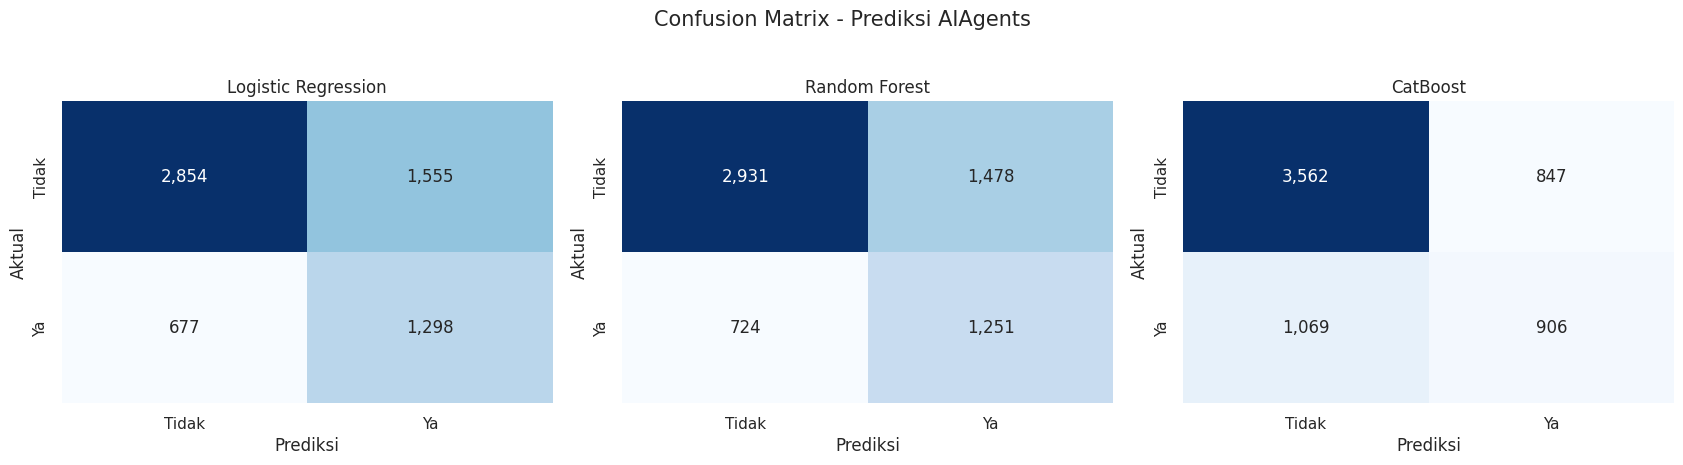

Ringkasan F1-score:


,Model,F1 Tidak,F1 Ya,F1 Macro
2,CatBoost,0.7881,0.4861,0.6371
1,Random Forest,0.7269,0.5319,0.6294
0,Logistic Regression,0.7189,0.5377,0.6283


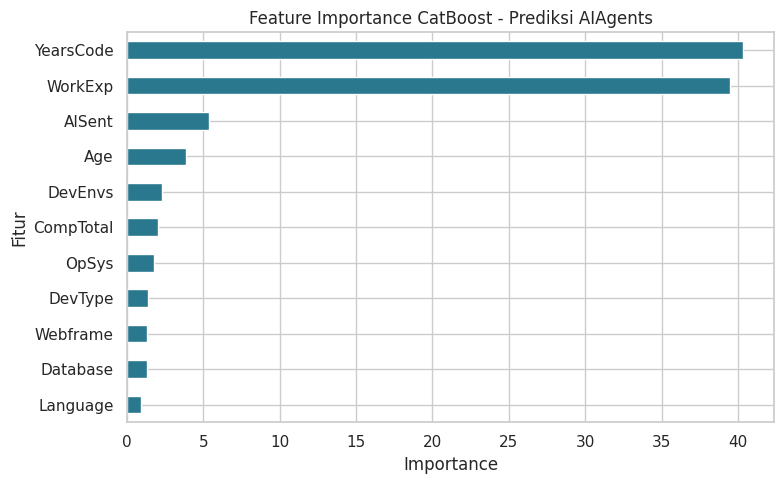

Training awal: 25,535 | setelah SMOTENC: 35,270 | testing: 6,384


In [8]:
result_ai_agents = train_and_evaluate(X, Y_2, 'Prediksi AIAgents')

## 8. Optimasi Skenario B

Optimasi membandingkan class weighting dan random under-sampling. Test set tetap memakai distribusi asli; penyeimbangan hanya dilakukan pada training set.

### 8.1 Hyperparameter tuning CatBoost

`GridSearchCV` mencari kombinasi `depth`, `learning_rate`, dan `l2_leaf_reg` terbaik menggunakan `F1 Macro`.

In [10]:
valid_target = Y_2.notna()
X_optimization = X.loc[valid_target].copy()
y_optimization = Y_2.loc[valid_target].astype(int)

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_optimization,
    y_optimization,
    test_size=0.20,
    stratify=y_optimization,
    random_state=RANDOM_STATE,
)

for column in CATEGORICAL_FEATURES:
    X_train_opt[column] = X_train_opt[column].fillna('Tidak diketahui').astype(str)
    X_test_opt[column] = X_test_opt[column].fillna('Tidak diketahui').astype(str)

for column in NUMERIC_FEATURES:
    train_values = pd.to_numeric(X_train_opt[column], errors='coerce')
    test_values = pd.to_numeric(X_test_opt[column], errors='coerce')
    median = train_values.median()
    X_train_opt[column] = train_values.fillna(median)
    X_test_opt[column] = test_values.fillna(median)

# Pindahkan cat_features keluar dari constructor untuk menghindari error kloning
catboost_search = CatBoostClassifier(
    iterations=200,
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=2,
)

catboost_params = {
    'depth': [4, 6],
    'learning_rate': [0.05, 0.10],
    'l2_leaf_reg': [1, 5],
}

grid_search = GridSearchCV(
    estimator=catboost_search,
    param_grid=catboost_params,
    scoring='f1_macro',
    cv=3,
    verbose=1,
)

print('Memulai hyperparameter tuning CatBoost...')
# Berikan cat_features di sini
grid_search.fit(X_train_opt, y_train_opt, cat_features=CATEGORICAL_FEATURES)

print(f'Parameter terbaik: {grid_search.best_params_}')
best_catboost = grid_search.best_estimator_
y_pred_catboost_tuned = best_catboost.predict(X_test_opt).astype(int).ravel()
catboost_tuned_metrics = metric_row(
    'CatBoost (Class Weight + Tuned)',
    y_test_opt,
    y_pred_catboost_tuned,
)

print('\nClassification Report - CatBoost Tuned')
print(
    classification_report(
        y_test_opt,
        y_pred_catboost_tuned,
        target_names=['Tidak', 'Ya'],
        digits=4,
        zero_division=0,
    )
)

Memulai hyperparameter tuning CatBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Parameter terbaik: {'depth': 6, 'l2_leaf_reg': 1, 'learning_rate': 0.1}

Classification Report - CatBoost Tuned
              precision    recall  f1-score   support

       Tidak     0.8250    0.6659    0.7369      4409
          Ya     0.4786    0.6846    0.5633      1975

    accuracy                         0.6717      6384
   macro avg     0.6518    0.6752    0.6501      6384
weighted avg     0.7178    0.6717    0.6832      6384



### 8.2 Random under-sampling

Training set diseimbangkan menjadi 50:50. Test set tidak diubah agar evaluasi tetap mencerminkan distribusi data asli.

Training sebelum under-sampling: 25,535
Training setelah under-sampling: 15,800
Test dengan distribusi asli: 6,384
Melatih Logistic Regression...
Melatih Random Forest...
Melatih CatBoost...


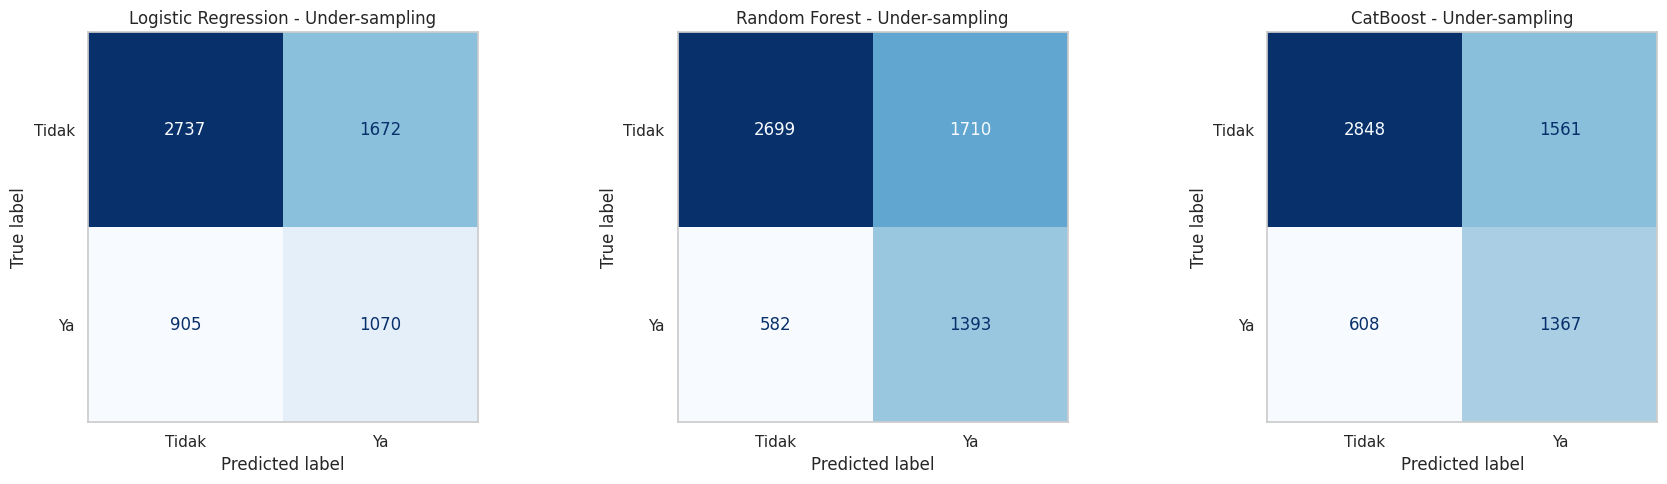

Ringkasan performa under-sampling:


,Model,F1 Tidak,F1 Ya,F1 Macro
2,CatBoost,0.7242,0.5576,0.6409
1,Random Forest,0.7020,0.5486,0.6253
0,Logistic Regression,0.6799,0.4537,0.5668


In [11]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_res, y_train_res = rus.fit_resample(X_train_opt, y_train_opt)
X_test_res, y_test_res = X_test_opt, y_test_opt

print(f'Training sebelum under-sampling: {len(y_train_opt):,}')
print(f'Training setelah under-sampling: {len(y_train_res):,}')
print(f'Test dengan distribusi asli: {len(y_test_res):,}')


def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                'cat',
                OneHotEncoder(handle_unknown='ignore', dtype=np.float32),
                CATEGORICAL_FEATURES,
            )
        ],
        remainder='passthrough',
    )


models_balanced = {
    'Logistic Regression': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('scaler', StandardScaler(with_mean=False)),
        ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', RandomForestClassifier(
            n_estimators=100,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    'CatBoost': CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=5,
        verbose=False,
        allow_writing_files=False,
        random_seed=RANDOM_STATE,
        thread_count=2,
    ),
}

balanced_predictions = {}
balanced_rows = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, (model_name, model) in zip(axes, models_balanced.items()):
    print(f'Melatih {model_name}...')
    if model_name == 'CatBoost':
        model.fit(X_train_res, y_train_res, cat_features=CATEGORICAL_FEATURES)
    else:
        model.fit(X_train_res, y_train_res)

    y_pred = np.asarray(model.predict(X_test_res)).astype(int).ravel()
    balanced_predictions[model_name] = y_pred
    balanced_rows.append(metric_row(model_name, y_test_res, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test_res,
        y_pred,
        display_labels=['Tidak', 'Ya'],
        cmap='Blues',
        colorbar=False,
        ax=axis,
    )
    axis.set_title(f'{model_name} - Under-sampling')
    axis.grid(False)

plt.tight_layout()
plt.show()

balanced_results = pd.DataFrame(balanced_rows).sort_values('F1 Macro', ascending=False)
print('Ringkasan performa under-sampling:')
display(balanced_results.style.format({
    'F1 Tidak': '{:.4f}',
    'F1 Ya': '{:.4f}',
    'F1 Macro': '{:.4f}',
}))

### 8.3 Hyperparameter tuning Logistic Regression

Nilai `C` dipilih menggunakan cross-validation pada training set hasil under-sampling.

In [12]:
logreg_pipeline = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('scaler', StandardScaler(with_mean=False)),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

logreg_params = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
    'model__penalty': ['l2'],
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_params,
    cv=3,
    scoring='f1_macro',
    verbose=1,
)

print('Mencari parameter terbaik untuk Logistic Regression...')
logreg_grid.fit(X_train_res, y_train_res)

print(f'Parameter terbaik: {logreg_grid.best_params_}')
y_pred_logreg_tuned = logreg_grid.predict(X_test_res)
logreg_tuned_metrics = metric_row(
    'Logistic Regression (Under-sampling + Tuned)',
    y_test_res,
    y_pred_logreg_tuned,
)

print('\nClassification Report - Logistic Regression Tuned')
print(
    classification_report(
        y_test_res,
        y_pred_logreg_tuned,
        target_names=['Tidak', 'Ya'],
        digits=4,
        zero_division=0,
    )
)

Mencari parameter terbaik untuk Logistic Regression...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Parameter terbaik: {'model__C': 0.01, 'model__penalty': 'l2'}

Classification Report - Logistic Regression Tuned
              precision    recall  f1-score   support

       Tidak     0.7683    0.6391    0.6978      4409
          Ya     0.4142    0.5696    0.4796      1975

    accuracy                         0.6176      6384
   macro avg     0.5912    0.6044    0.5887      6384
weighted avg     0.6587    0.6176    0.6303      6384



### 8.4 Hyperparameter tuning Random Forest

Jumlah pohon, kedalaman, dan minimum sampel daun dipilih menggunakan `F1 Macro`.

In [13]:
rf_pipeline = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
])

rf_params = {
    'model__n_estimators': [100, 150],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_leaf': [2, 5],
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=3,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1,
)

print('Mencari parameter terbaik untuk Random Forest...')
rf_grid.fit(X_train_res, y_train_res)

print(f'Parameter terbaik: {rf_grid.best_params_}')
y_pred_rf_tuned = rf_grid.predict(X_test_res)
rf_tuned_metrics = metric_row(
    'Random Forest (Under-sampling + Tuned)',
    y_test_res,
    y_pred_rf_tuned,
)

print('\nClassification Report - Random Forest Tuned')
print(
    classification_report(
        y_test_res,
        y_pred_rf_tuned,
        target_names=['Tidak', 'Ya'],
        digits=4,
        zero_division=0,
    )
)

Mencari parameter terbaik untuk Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Parameter terbaik: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 150}

Classification Report - Random Forest Tuned
              precision    recall  f1-score   support

       Tidak     0.8219    0.6217    0.7079      4409
          Ya     0.4529    0.6992    0.5498      1975

    accuracy                         0.6457      6384
   macro avg     0.6374    0.6605    0.6288      6384
weighted avg     0.7077    0.6457    0.6590      6384



## 9. Perbandingan hasil optimasi

Tabel dibuat langsung dari prediksi model, tanpa nilai metrik hardcoded.

In [14]:
optimized_results = (
    pd.DataFrame([
        catboost_tuned_metrics,
        logreg_tuned_metrics,
        rf_tuned_metrics,
    ])
    .sort_values('F1 Macro', ascending=False)
    .reset_index(drop=True)
)

print('Ringkasan performa optimasi AIAgents:')
display(optimized_results.style.format({
    'F1 Tidak': '{:.4f}',
    'F1 Ya': '{:.4f}',
    'F1 Macro': '{:.4f}',
}))

Ringkasan performa optimasi AIAgents:


,Model,F1 Tidak,F1 Ya,F1 Macro
0,CatBoost (Class Weight + Tuned),0.7369,0.5633,0.6501
1,Random Forest (Under-sampling + Tuned),0.7079,0.5498,0.6288
2,Logistic Regression (Under-sampling + Tuned),0.6978,0.4796,0.5887


### 9.1 Feature importance Random Forest

Plot menampilkan 15 fitur teratas dari Random Forest hasil tuning.

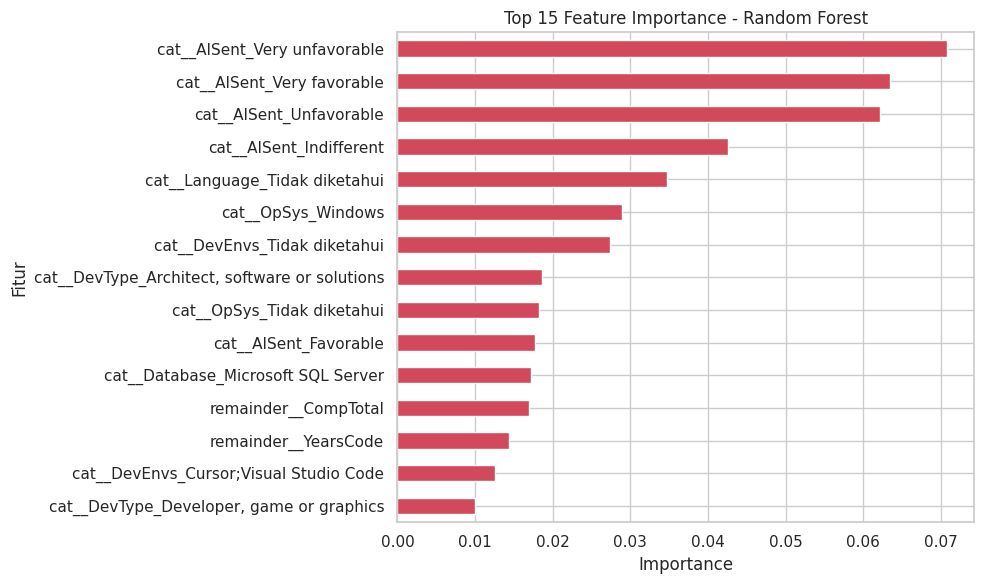

In [15]:
best_rf_pipeline = rf_grid.best_estimator_
best_rf = best_rf_pipeline.named_steps['model']
feature_names = best_rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

rf_importance = pd.Series(best_rf.feature_importances_, index=feature_names)
top_rf_importance = rf_importance.nlargest(15).sort_values()

top_rf_importance.plot.barh(figsize=(10, 6), color='#d1495b')
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

## 10. Perbandingan seluruh skenario

In [16]:
summary_final = pd.concat([
    result_ai_select['summary'].assign(Skenario='AISelect - Awal'),
    result_ai_agents['summary'].assign(Skenario='AIAgents - Awal'),
    optimized_results.assign(Skenario='AIAgents - Optimasi'),
], ignore_index=True)

summary_final = summary_final.sort_values(['Skenario', 'F1 Macro'], ascending=[True, False])
print('Tabel perbandingan performa keseluruhan:')
display(summary_final.style.format({
    'F1 Tidak': '{:.4f}',
    'F1 Ya': '{:.4f}',
    'F1 Macro': '{:.4f}',
}))

best_models = summary_final.loc[
    summary_final.groupby('Skenario')['F1 Macro'].idxmax(),
    ['Skenario', 'Model', 'F1 Tidak', 'F1 Ya', 'F1 Macro'],
]
print('\nModel terbaik per skenario:')
display(best_models.reset_index(drop=True))

Tabel perbandingan performa keseluruhan:


,Model,F1 Tidak,F1 Ya,F1 Macro,Skenario
3,CatBoost,0.7881,0.4861,0.6371,AIAgents - Awal
4,Random Forest,0.7269,0.5319,0.6294,AIAgents - Awal
5,Logistic Regression,0.7189,0.5377,0.6283,AIAgents - Awal
6,CatBoost (Class Weight + Tuned),0.7369,0.5633,0.6501,AIAgents - Optimasi
7,Random Forest (Under-sampling + Tuned),0.7079,0.5498,0.6288,AIAgents - Optimasi
8,Logistic Regression (Under-sampling + Tuned),0.6978,0.4796,0.5887,AIAgents - Optimasi
0,CatBoost,0.6723,0.9079,0.7901,AISelect - Awal
1,Random Forest,0.6712,0.8906,0.7809,AISelect - Awal
2,Logistic Regression,0.6628,0.8856,0.7742,AISelect - Awal



Model terbaik per skenario:


,Skenario,Model,F1 Tidak,F1 Ya,F1 Macro
0,AIAgents - Awal,CatBoost,0.788053,0.486052,0.637052
1,AIAgents - Optimasi,CatBoost (Class Weight + Tuned),0.736948,0.563333,0.650141
2,AISelect - Awal,CatBoost,0.672297,0.907865,0.790081


## 11. Kesimpulan dan catatan interpretasi

- Gunakan `F1 Macro` untuk membandingkan performa antarkelas; accuracy saja dapat menutupi kegagalan pada kelas minoritas.
- Under-sampling hanya diterapkan pada training set. Test set mempertahankan distribusi asli.
- Model terbaik dibaca dari tabel dinamis setelah seluruh sel dijalankan.
- Feature importance menunjukkan asosiasi prediktif, bukan hubungan sebab-akibat.